In [1]:
%load_ext autoreload
%autoreload 2

z_star: 11.0
Avg. cost: 29.135936737060547


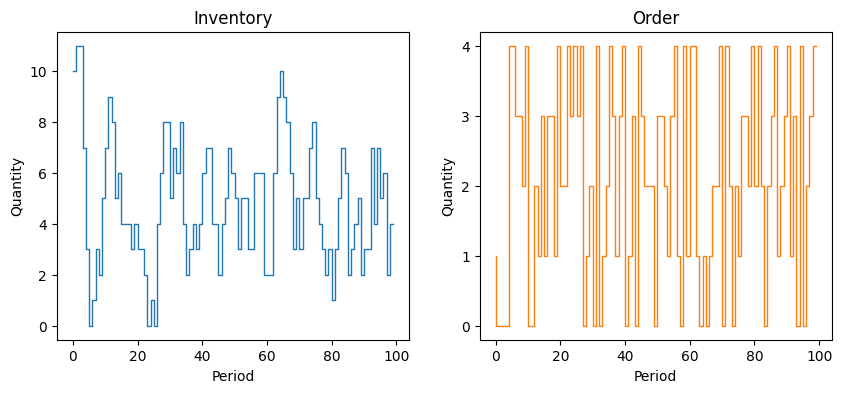

In [43]:
from idinn.sourcing_model import SingleSourcingModel
from idinn.single_controller import BaseStockController
from idinn.demand import UniformDemand

single_sourcing_model = SingleSourcingModel(
    lead_time=2,
    holding_cost=5,
    shortage_cost=495,
    batch_size=32,
    init_inventory=10,
    demand_generator=UniformDemand(low=0, high=4),
)
controller_base = BaseStockController()
# z_star should be 11
controller_base.fit(single_sourcing_model)
print(f"z_star: {controller_base.z_star}")
# Avg. cost near 29
avg_cost = controller_base.get_average_cost(single_sourcing_model, sourcing_periods=1000)
print(f"Avg. cost: {avg_cost}")
# Simulate
past_inventories, past_orders = controller_base.simulate(single_sourcing_model, sourcing_periods=100)
# Plot
controller_base.plot(single_sourcing_model, sourcing_periods=100)

z_star: 4.0
Avg. cost: 10.1107816696167


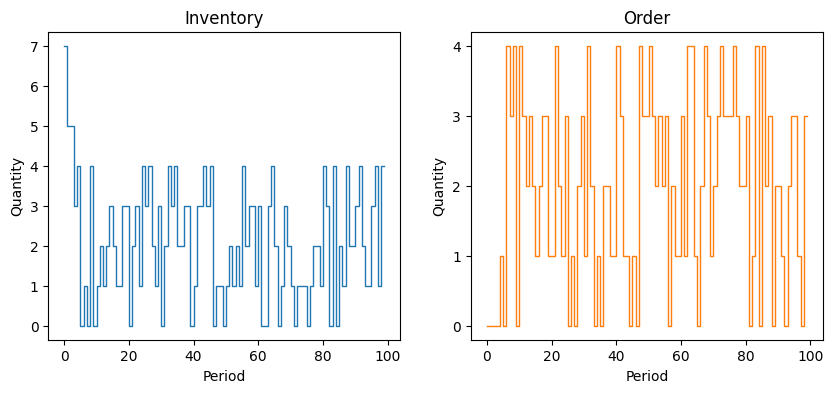

In [15]:
single_sourcing_model = SingleSourcingModel(
    lead_time=0,
    holding_cost=5,
    shortage_cost=495,
    batch_size=32,
    init_inventory=10,
    demand_generator=UniformDemand(low=0, high=4),
 )
controller_base = BaseStockController()
# z_star should be 4
controller_base.fit(single_sourcing_model)
print(f"z_star: {controller_base.z_star}")
# Avg. cost near 10
avg_cost = controller_base.get_average_cost(single_sourcing_model, sourcing_periods=1000)
print(f"Avg. cost: {avg_cost}")
# Simulate
past_inventories, past_orders = controller_base.simulate(single_sourcing_model, sourcing_periods=100)
# Plot
controller_base.plot(single_sourcing_model, sourcing_periods=100)

Avg. cost: 7.572500228881836


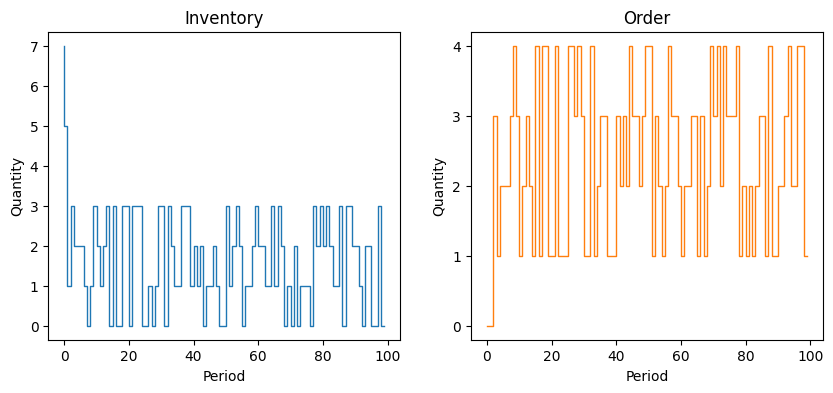

In [ ]:
from idinn.sourcing_model import SingleSourcingModel
from idinn.single_controller import SingleSourcingNeuralController
from idinn.demand import UniformDemand
from torch.utils.tensorboard import SummaryWriter

single_sourcing_model = SingleSourcingModel(
    lead_time=0,
    holding_cost=5,
    shortage_cost=495,
    batch_size=32,
    init_inventory=10,
    demand_generator=UniformDemand(low=1, high=4),
)

controller_neural = SingleSourcingNeuralController()
controller_neural.fit(
    sourcing_model=single_sourcing_model,
    sourcing_periods=50,
    validation_sourcing_periods=1000,
    epochs=2000,
    tensorboard_writer=SummaryWriter(comment="_single_1"),
    seed=1,
)
# Avg. cost near 7.57
avg_cost = controller_neural.get_average_cost(single_sourcing_model, sourcing_periods=1000)
print(f"Avg. cost: {avg_cost}")
# Simulate
past_inventories, past_orders = controller_neural.simulate(single_sourcing_model, sourcing_periods=100)
# Plot
controller_base.plot(single_sourcing_model, sourcing_periods=100)

Avg. cost: 25.260000228881836


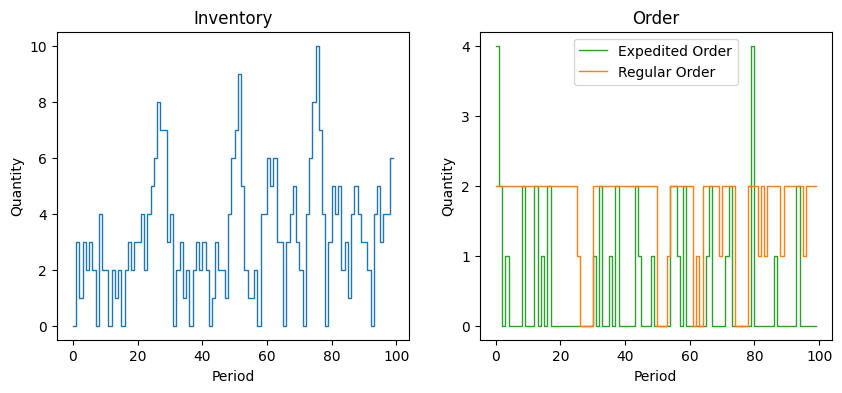

In [ ]:
from idinn.sourcing_model import DualSourcingModel
from idinn.dual_controller import CappedDualIndexController
from idinn.demand import UniformDemand

dual_sourcing_model = DualSourcingModel(
    regular_lead_time=2,
    expedited_lead_time=0,
    regular_order_cost=0,
    expedited_order_cost=20,
    holding_cost=5,
    shortage_cost=495,
    init_inventory=0,
    demand_generator=UniformDemand(low=0, high=4)
)
controller_cdi = CappedDualIndexController()
controller_cdi.fit(
    dual_sourcing_model,
    sourcing_periods=100
)
controller_cdi.get_average_cost(dual_sourcing_model, sourcing_periods=1000)
# Avg. cost near 25.26
avg_cost = controller_cdi.get_average_cost(dual_sourcing_model, sourcing_periods=1000, seed=42)
print(f"Avg. cost: {avg_cost}")
# Simulate
past_inventories, past_regular_orders, past_expedited_orders = controller_cdi.simulate(dual_sourcing_model, sourcing_periods=100, seed=42)
# Plot
controller_cdi.plot(dual_sourcing_model, sourcing_periods=100, seed=42)

In [64]:
import numpy as np

controller_cdi.predict(
    current_inventory=3, past_regular_orders=np.array([[1, 1, 1]]), past_expedited_orders=np.array([[0, 0, 0]])
)

(np.int64(2), 0)

Avg. cost: 24.049999237060547


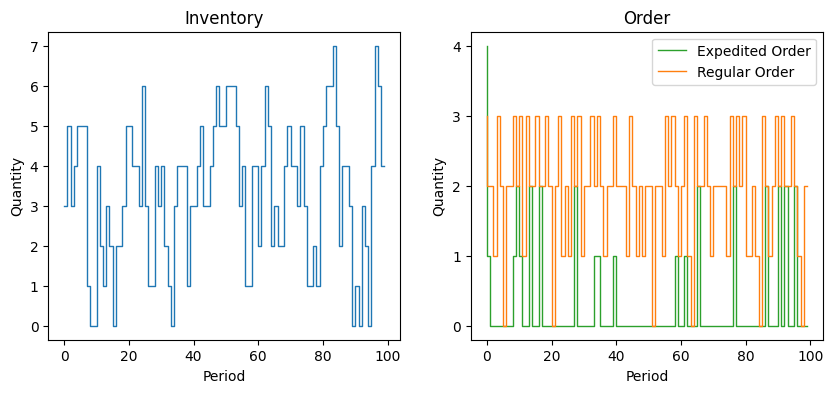

In [ ]:
from idinn.sourcing_model import DualSourcingModel
from idinn.dual_controller import DynamicProgrammingController
from idinn.demand import UniformDemand

dual_sourcing_model = DualSourcingModel(
    regular_lead_time=2,
    expedited_lead_time=0,
    regular_order_cost=0,
    expedited_order_cost=20,
    holding_cost=5,
    shortage_cost=495,
    init_inventory=0,
    demand_generator=UniformDemand(low=0, high=4)
)
controller_dp = DynamicProgrammingController()
controller_dp.fit(
    dual_sourcing_model,
    max_iterations=10000,
    tolerance=1e-6
)
# Avg. cost near 24
avg_cost = controller_dp.get_average_cost(dual_sourcing_model, sourcing_periods=1000)
print(f"Avg. cost: {avg_cost}")
# Simulate
past_inventories, past_regular_orders, past_expedited_orders = controller_dp.simulate(dual_sourcing_model, sourcing_periods=100)
# Plot
controller_dp.plot(dual_sourcing_model, sourcing_periods=100)

Avg. cost: 29.486719131469727


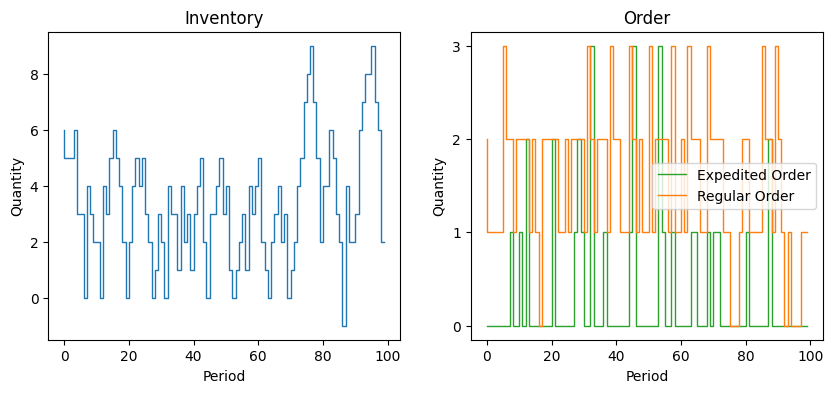

In [ ]:
import torch
from idinn.sourcing_model import DualSourcingModel
from idinn.dual_controller import DualSourcingNeuralController
from idinn.demand import UniformDemand
from torch.utils.tensorboard import SummaryWriter

dual_sourcing_model = DualSourcingModel(
    regular_lead_time=2,
    expedited_lead_time=0,
    regular_order_cost=0,
    expedited_order_cost=20,
    holding_cost=5,
    shortage_cost=495,
    batch_size=256,
    init_inventory=6,
    demand_generator=UniformDemand(low=0, high=4),
)
controller_neural = DualSourcingNeuralController(
    hidden_layers=[128, 64, 32, 16, 8, 4],
    activation=torch.nn.CELU(alpha=1)
)
controller_neural.fit(
    sourcing_model=dual_sourcing_model,
    sourcing_periods=100,
    validation_sourcing_periods=1000,
    epochs=2000,
    tensorboard_writer=SummaryWriter(comment="_dual_4"),
    seed=1234,
)
# Avg. cost near 29.48
avg_cost = controller_neural.get_average_cost(dual_sourcing_model, sourcing_periods=1000)
print(f"Avg. cost: {avg_cost}")
# Simulate
past_inventories, past_regular_orders, past_expedited_orders = controller_neural.simulate(dual_sourcing_model, sourcing_periods=100)
# Plot
controller_neural.plot(dual_sourcing_model, sourcing_periods=100)

In [66]:
from idinn.sourcing_model import DualSourcingModel
from idinn.demand import CustomDemand

sourcing_model = DualSourcingModel(
    regular_lead_time=3,
    expedited_lead_time=0,
    regular_order_cost=0,
    expedited_order_cost=20,
    holding_cost=5,
    shortage_cost=495,
    init_inventory=0,
    demand_generator=CustomDemand({5: 0.999, 6: 0.001})
)

In [79]:
sourcing_model.demand_generator.sample(10)

tensor([[5],
        [5],
        [5],
        [5],
        [5],
        [5],
        [5],
        [5],
        [5],
        [5]])

In [71]:
sourcing_model.get_past_inventories()

tensor([[  0.,   0.,   0.,   0.,  -4.,  -8., -12., -11., -10.,  -5.,   0.,   5.,
           5.,   5.]], grad_fn=<CatBackward0>)

In [ ]:
demand_prob = {5: 0.2, 6: 0.3, 7: 0.1, 8: 0.1, 9: 0.1}
# Draw dictionary keys with corresponding probabilities
index = torch.multinomial(torch.tensor(list(demand_prob.values())), num_samples=10, replacement=True)
torch.tensor(list(demand_prob.keys()))[index]

# Use torch multinomial to sample from dictionary demand_prob
index = torch.multinomial(torch.tensor(list(demand_prob.values())), num_samples=10, replacement=True)

torch.tensor(list(demand_prob.keys()))[index]

In [ ]:
import numpy as np
current_inventory = 10
regular_lead_time = 5
expedited_lead_time = 2
past_regular_orders = np.array([1, 2, 3, 4, 5, 6, 7, 8])
past_expedited_orders = np.array([6, 7, 8])
# Output:
past_orders = [4, 5, 6, 7, 8]

# Pad with zeros for past_expedited_orders
# e_2 = np.pad(e_2, (0, 3), 'constant')
# Start with np.zeros before padding
e_1 = np.zeros(regular_lead_time)
e_1 = past_regular_orders[-regular_lead_time:]

e_2 = np.zeros(regular_lead_time)
e_2[:expedited_lead_time] = past_expedited_orders[-expedited_lead_time:]
e_3 = e_1 + e_2

first = current_inventory + e_3[0]
second = e_3[-regular_lead_time+1:]
print(tuple([first]+second))

In [ ]:
first =  past_regular_orders[-regular_lead_time]
second = past_regular_orders[-regular_lead_time+1:]
print(tuple([first]+second))